# Поиск инсайтов и точек роста
Нам нужно помочь бизнесу ответить на следующие вопросы:

- Как ведут себя пользователи? Как наиболее эффективно выстроить работу с ними, чтобы они продолжали пользоваться продуктом?
- Какой путь проходят пользователи в сервисе? Где «проваливаются»?
- Как улучшить взаимодействие с партнёрами-ресторанами?

### Задачи

В рамках данного проекта проведём комплексный анализ данных:

- изучим пользовательский путь и проанализируем конверсии через воронки
- сегментируем пользователей с помощью RFM-модели для оценки лояльности и поведения клиентов
- кластеризуем рестораны методом K-Means, чтобы выделить группы с разными моделями работы и разработать персонализированные маркетинговые стратегии

Такой подход позволит ближе познакомиться с работой сервиса, выявить узкие места и предложить решения для удержания пользователей и повышения эффективности сотрудничества с ресторанами.


### Данные

Данные включают следующие сведения:
      
- `visitor_uuid` — идентификатор посетителя. Это идентификатор, который присваивается системой любому новому пользователю вне зависимости от того, зарегистрировался он в продукте или нет.
- `user_id` — идентификатор зарегистрированного пользователя. Присваивается посетителю после создания учётной записи: ввода логина, пароля, адреса доставки и контактных данных.
- `device_type` — тип платформы, с которой посетитель зашёл в продукт.
- `city_id` — город, из которого посетитель зашёл в сервис.
- `source` — рекламный источник привлечения посетителя.
- `first_date` — дата первого посещения продукта.
- `visit_id` — уникальный идентификатор сессии.
- `event` — название аналитического события.
- `datetime` — дата и время события.
- `rest_id` — уникальный идентификатор ресторана (заполняется для заказов, карточек ресторанов и блюд).
- `object_id` — уникальный идентификатор блюда (заполняется для заказов и карточек блюд).
- `order_id` — уникальный идентификатор заказа.
- `revenue` — выручка от заказа (в рублях). Это та сумма, которую пользователь видит при оплате.
- `delivery` — стоимость доставки (в рублях).
- `commission` — комиссия, которую «Всё.из.кафе» берёт с выручки ресторана, в процентах.

    
### План проекта
- Загрузка данных и их предобработка.
- Анализ пользовательского пути новых пользователей.
- RFM сегментация.
- K-Means кластеризация.
- Итоговый вывод и рекомендации.

## 1. Загрузка данных и их предобработка

Загрузите данные и получите первую информацию о них. Проведите необходимую предобработку. Основную информацию о данных и этапы предобработки зафиксируйте в кратком промежуточном выводе.

In [1]:
# импорты библиотек
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [ ]:
# загрузка данных
insides = pd.read_csv(
    'секретная_информация/insides_data.csv',
    parse_dates=['first_date', 'datetime']
)

In [3]:
# проверка корректности 
insides.head()

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission
0,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,authorization,2021-05-01 16:07:53,NaN,NaN,NaN,NaN,NaN,NaN
1,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,reg_page,2021-05-01 16:09:16,NaN,NaN,NaN,NaN,NaN,NaN
2,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,confirm_phone,2021-05-01 16:09:19,NaN,NaN,NaN,NaN,NaN,NaN
3,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,login,2021-05-01 16:09:23,NaN,NaN,NaN,NaN,NaN,NaN
4,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:09:34,2c6095730b514c189ee41c65f03febc3,NaN,NaN,NaN,NaN,NaN


In [4]:
# проверка типов
insides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  float64       
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int64         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int64         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float64       
 11  order_id      7008 non-null    float64       
 12  revenue       7008 non-null    float64       
 13  delivery      7008 non-null    float64       
 14  commission    21308 non-null   float64       
dtypes: datetime64[ns]

In [5]:
insides[['user_id', 'object_id', 'order_id']] = insides[['user_id', 'object_id', 'order_id']].astype('Int64')

In [6]:
# проверка дубликатов
insides.duplicated().sum()

np.int64(0)

### Промежуточный вывод.  
Дубликаты не обнаружены, типы соответствуют данным. Пропуски - следствие специфики продукта (например, у пользователей не совершавших заказ, отсутствуют id заказа, выручка, адрес доставки, данные о комиссии).

---

## 2. Анализ пользовательского пути

Маркетологи стали замечать следующее: деньги на рекламу по-прежнему тратятся, а заказов стало меньше. И это несмотря на то, что приложение скачивается и устанавливается так же активно, как раньше. Складывается ощущение, что пользователи где-то теряются. При этом доля заказов с десктопной версии приложения увеличилась по сравнению с мобильной.

Разработчики говорят, что последние обновления мобильной версии приложения не должны были повлиять на каталог блюд или его выбор для заказа и последующей оплаты доставки, так как изменения касались нового алгоритма подтверждения мобильного телефона и адреса доставки.

С помощью воронок изучим общий пользовательский путь новых пользователей, затем сравним поведение пользователей мобильной и десктопной версий приложения.

**Задача 2.1.**    
Построим и визуализируем общую воронку (по всем данным), затем опишем пользовательский путь: какие этапы представлены,    
какова их последовательность, на каком (или на каких) этапах теряется большая часть новых пользователей.

При решении построим две воронки:

- классическую воронку — доля от первого шага в процентах
- step-by-step — с конверсией от предыдущего этапа

Предполагается, что пользователь проходит такой путь к оформлению доставки блюда из ресторанов:
1. `authorization` — авторизация пользователя — запуск приложения.
2. `main_page` — загрузка основной страницы приложения.
2. `reg_page` — переход на страницу регистрации.
2. `confirm_phone` — подтверждение телефона (окончание процесса регистрации).
2. `object_page` — страница блюда.
2. `add_to_cart` — переход в корзину.
2. `order` — оформление заказа.    

In [7]:
# проанализируем воронки
steps = ['authorization', 'main_page', 'reg_page', 'confirm_phone', 'object_page',
         'add_to_cart', 'order']

funnel_df = insides[insides['event'].isin(steps)]
funnel_df = funnel_df.groupby('event')['user_id']\
    .nunique().reindex(steps).reset_index()
funnel_df = funnel_df.rename(columns={'user_id': 'user_count'})
funnel_df['conversion_%'] = funnel_df['user_count'] / funnel_df['user_count'].loc[0] * 100
funnel_df['conversion_step_by_step_%'] = funnel_df['user_count'] / funnel_df['user_count'].shift(1) * 100
funnel_df


,event,user_count,conversion_%,conversion_step_by_step_%
0,authorization,7410,100.000000,NaN
1,main_page,6537,88.218623,88.218623
2,reg_page,5417,73.103914,82.866758
3,confirm_phone,4190,56.545209,77.349086
4,object_page,3453,46.599190,82.410501
5,add_to_cart,2899,39.122807,83.955980
6,order,2416,32.604588,83.339082


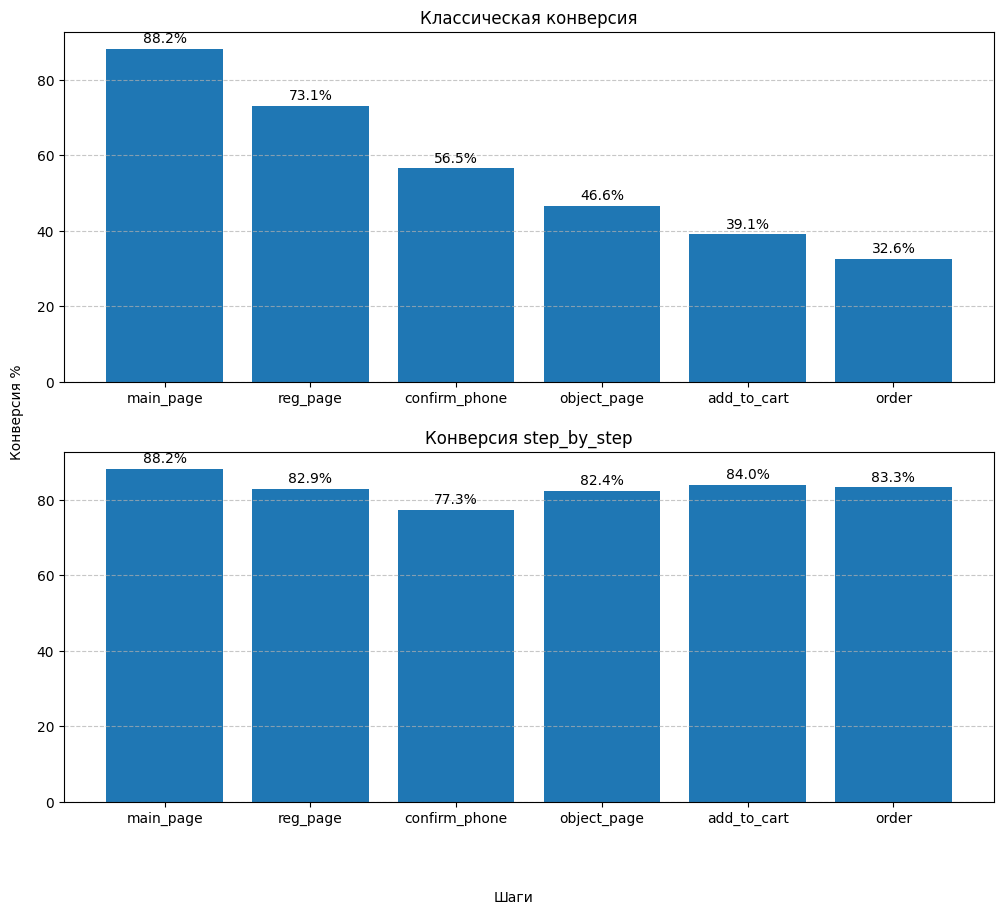

In [26]:
# визуализируем
funnel_df_plot = funnel_df[funnel_df['event'] != 'authorization']
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# первый график: классическая конверсия
bars0 = axes[0].bar(funnel_df_plot['event'], funnel_df_plot['conversion_%'])
axes[0].set_title('Классическая конверсия')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
# добавляем подписи над столбцами
axes[0].bar_label(bars0, fmt='%.1f%%', label_type='edge', padding=2)

# второй график: конверсия step_by_step
bars1 = axes[1].bar(funnel_df_plot['event'], funnel_df_plot['conversion_step_by_step_%'])
axes[1].set_title('Конверсия step_by_step')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
# добавляем подписи над столбцами
axes[1].bar_label(bars1, fmt='%.1f%%', label_type='edge', padding=2)

plt.subplots_adjust(hspace=0.2)

fig.text(0.5, 0.01, 'Шаги', ha='center')
fig.text(0.08, 0.5, 'Конверсия %', va='center', rotation='vertical')

plt.show()
    

## Промежуточный вывод.   
При классической воронке идет ожидаемое снижение количества пользователей на протяжении всего измерения.   
При step-by-step воронке, снижение особенно заметно на этапах main_page -> reg_page -> confirm_phone, что говорит о сложностях перехода. 

**Задача 2.2.**    
Сравним пользовательский путь в двух приложениях: в мобильной версии и десктопной.    
Для этого построим и визуализируем две воронки step-by-step: для новых пользователей мобильной и десктопной версий приложения.
  
Сравним результаты между собой и проанализируем, есть ли различия в пользовательском пути для различных приложений.

In [9]:
# функция для расчета S-B-S воронки и визуализации
def funnel_sbs(device_type: str):
    funnel_df_device = insides[(insides['event'].isin(steps)) & (insides['device_type'] == device_type)]
    funnel_df_device = funnel_df_device.groupby('event')['user_id'].nunique().reindex(steps).reset_index(name = 'user_c')
    funnel_df_device['conv_sbs'] = funnel_df_device.user_c / funnel_df_device.user_c.shift(1) * 100
    funnel_df_device = funnel_df_device[funnel_df_device['event'] != 'authorization']
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(funnel_df_device.event, funnel_df_device.conv_sbs)
    # Добавляем значения сверху столбцов
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height.round(2)}%',
             ha='center', va='bottom',
             fontsize=12)
    
    plt.gca().axes.get_yaxis().set_visible(False)    
    plt.title(f'Воронка конверсии {device_type}')
    plt.xlabel('Шаги')
    plt.show()



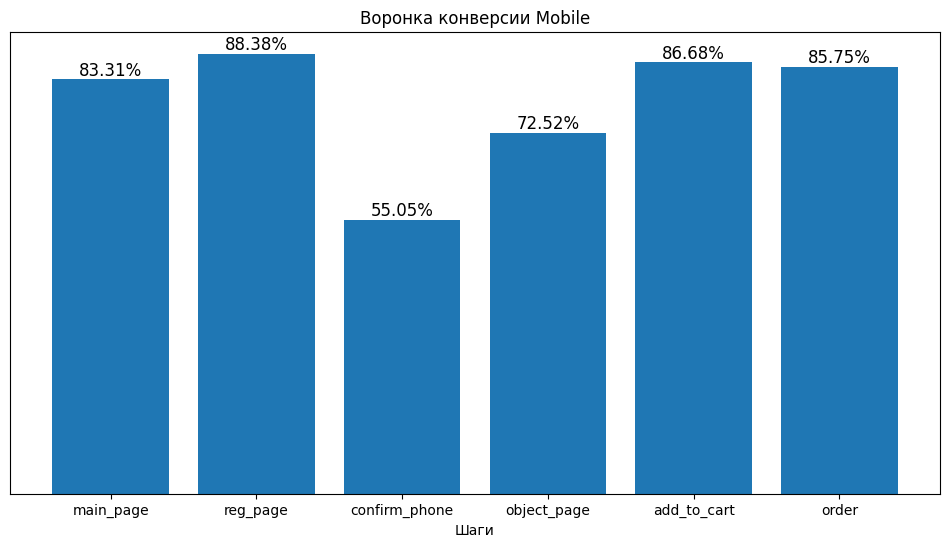

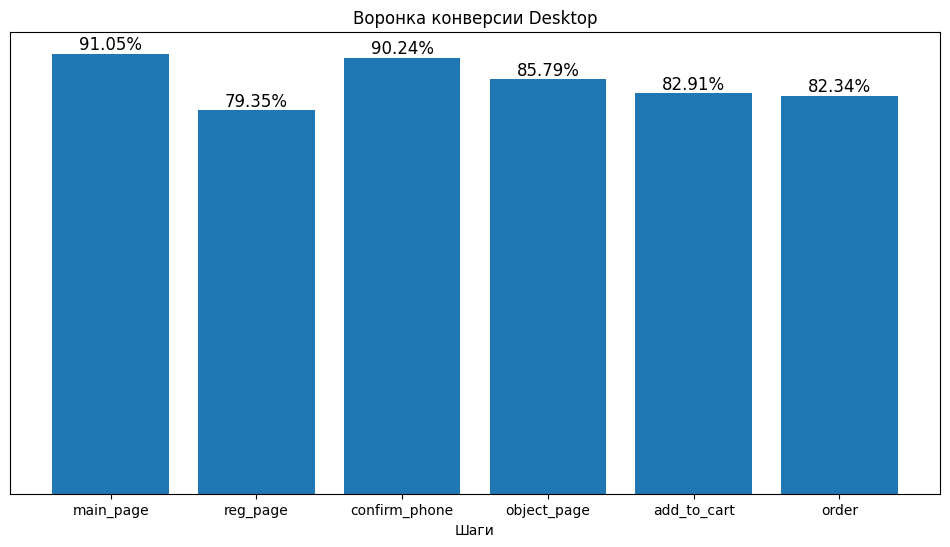

In [10]:
# выведем воронки s-b-s
funnel_sbs('Mobile')
funnel_sbs('Desktop')

### Промежуточный вывод.  
Анализ воронок step-by-step по типам устройств указывает на явную потерю доли пользователей при переходе:
 - Mobile с шага reg_page на шаг confirm_phone переходят лишь 55% пользователей
 - Desktop с шага main_page на шаг reg_page переходят 79% пользователей

---

## 3. RFM сегментация

У сервиса доставки еды не такое высокое удержание пользователей: в первый день возвращается около 14% посетителей, а на седьмой день и того меньше — около 4–5%. Маркетологи хотят запустить несколько рекламных кампаний, направленных на удержание платящих пользователей и их возврат в сервис, если они давно не совершали заказы.

Для этого необходимо сегментировать пользователей на различные поведенческие сегменты с помощью RFM-сегментации по трём показателям: 
- **давность** (Recency), 
- **частота покупок** (Frequency), 
- **сумма трат** (Monetary).

В качестве даты анализа установим **03 июля 2021 года**.

**Задача 3.1.**    
Для каждого покупателя посчитаем:

- количество дней с последней покупки — давность (R)
- частоту покупок (F)
- стоимость всех покупок — сумму трат (M)

В качестве даты анализа установим 03 июля 2021 года. После этого построим три гистограммы и проанализируем их.

In [11]:
analyze_dt = pd.to_datetime('2021-07-03')

In [12]:
rfm_df = insides.copy()

# оставим данные только с заказами и выручкой больше 0
rfm_df = rfm_df[(rfm_df['event'] == 'order') & (rfm_df['revenue'] > 0)].reset_index(drop=True)

rfm_df['order_recency'] = analyze_dt - rfm_df['datetime']

rfm_df = rfm_df.groupby('user_id').agg(
    recency = ('order_recency', lambda x: (x.min()).days),
    frequency = ('datetime', 'count'),
    monetary = ('revenue', 'sum')
).reset_index()


In [13]:
# функция для постройки гистограмм
def rmf_hist(df: pd.DataFrame, col: str):
    plt.figure(figsize=(12, 6))
    plt.hist(df[col], bins=75, edgecolor = 'white', linewidth = 0.5)
    
    if col == 'recency':
        plt.title('Количество дней с последней покупки')
        plt.xlabel('Дни')
    elif col == 'frequency':
        plt.title('Частота (число) заказов')
        plt.xlabel('Количество заказов')
    else:
        plt.title('Выручка (стоимость) заказов')
        plt.xlabel('Стоимость заказов')
    
    plt.ylabel('Количество пользователей')
    plt.show()

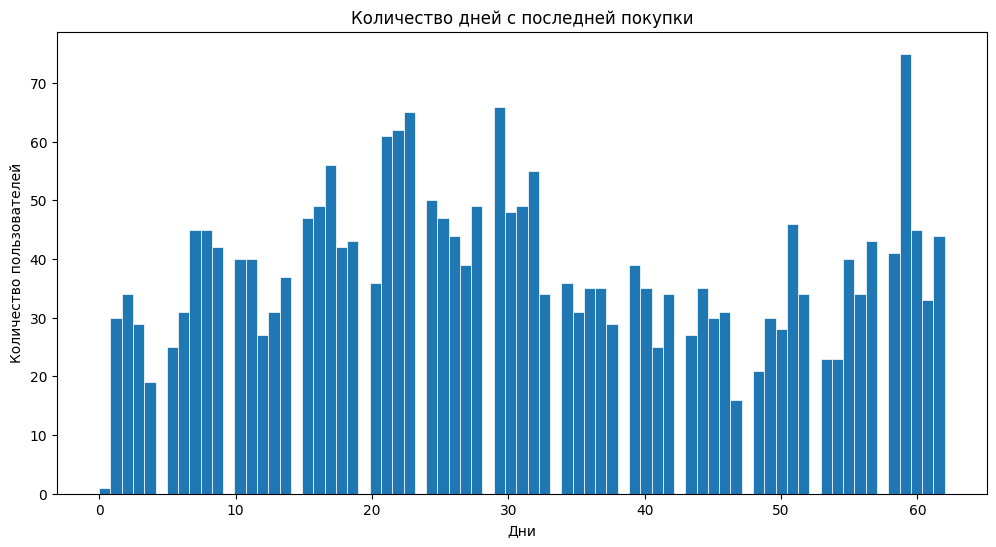

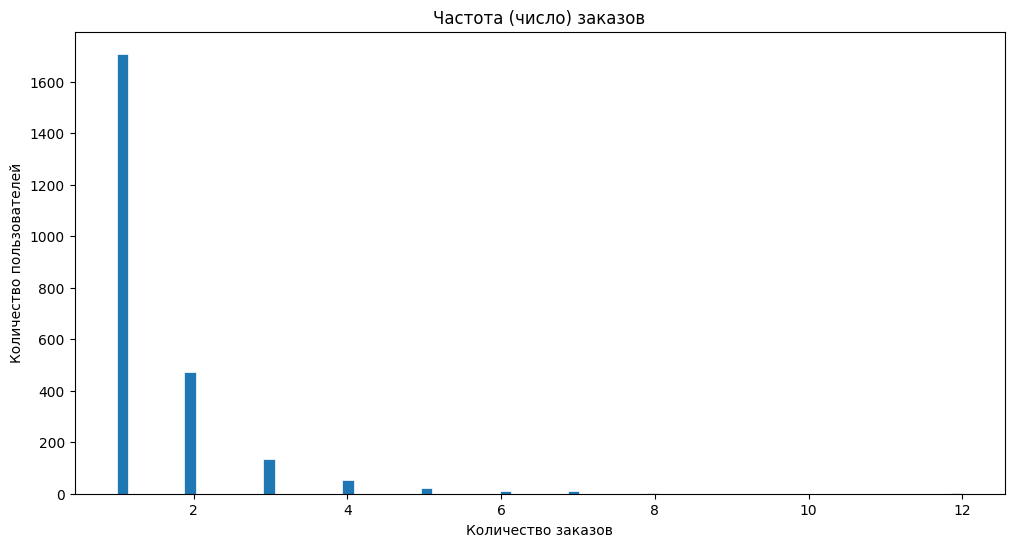

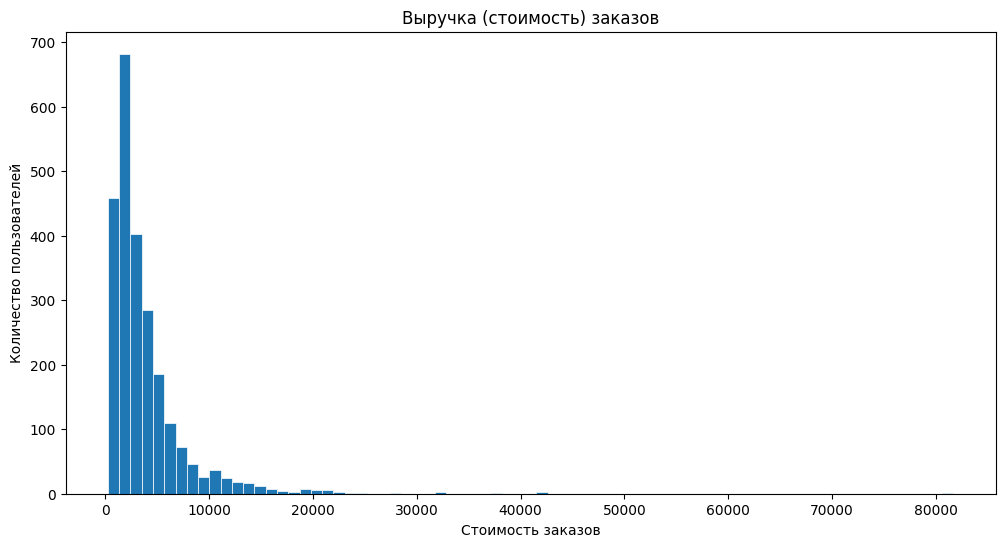

In [14]:
rmf_hist(rfm_df, 'recency')
rmf_hist(rfm_df, 'frequency')
rmf_hist(rfm_df, 'monetary')


## Промежуточный вывод.   
Количество дней с последней покупки - распределение растянуто, рекомендуется увеличивать вовлеченность пользователей для увеличения частоты посещения.   
Частота заказов - сдвинуто влево, число заказов маленькое - 1-2 у большинства. Рекомендуется ввести комбинированную корзину (бонусы или скидки при добавлении группы товаров).    
Стоимость заказов сконцентрирована в левой части графика, с сильным пиком около 1000 у.е.. Для увеличения среднего чека можно ввести систему кэшбэка, от высокой суммы заказа. 

**Задача 3.2.**    
Выделим RFM-сегменты и изучим распределение пользователей по ним.

Применим следующие подходы к выделению RFM сегментов:

- Recency — разделим на три равные группы
- Frequency — разделим на три группы: 
    - пользователи с 1 заказом (F-сегмент с небольшим количеством заказов)
    - пользователи с 2 заказами (F-сегмент со средним количеством заказов)
    - пользователи с 3 и более заказами (F-сегмент с большим количеством заказов)
- Monetary — разделим на три группы по 33-му и 66-му перцентилям

После этого посчитаем количество покупателей в каждом сегменте, сделаем промежуточные выводы и напишем рекомендации.

In [15]:
max_f = rfm_df.frequency.max()
rfm_df['r'] = pd.cut(rfm_df['recency'], bins=3, labels=[3, 2, 1])
rfm_df['f'] = pd.cut(rfm_df['frequency'], [0, 1, 2, max_f + 1], labels=[1, 2, 3], include_lowest=True)
rfm_df['m'] = pd.qcut(rfm_df['monetary'], q=3, labels=[1, 2, 3])

rfm_df[['r', 'f', 'm']] = rfm_df[['r', 'f', 'm']].astype('str')
rfm_df['rfm'] = rfm_df.r + rfm_df.f + rfm_df.m



In [16]:
rfm_df_group = rfm_df.groupby('rfm')['user_id'].nunique().reset_index().sort_values('user_id', ascending=False)
rfm_df_group['share_users_%'] = round(rfm_df_group['user_id'] / rfm_df_group['user_id'].sum() * 100, 2)

In [17]:
rfm_df_group

,rfm,user_id,share_users_%
8,211,281,11.63
0,111,247,10.22
17,311,246,10.18
9,212,237,9.81
1,112,216,8.94
18,312,186,7.70
10,213,122,5.05
13,223,115,4.76
16,233,102,4.22
19,313,99,4.10


## Промежуточный вывод.  
Самые важные группы - 333/332/323/233 - имеют малые доли от общего числа пользователей. 2.81%/0.21%/3.64%/4.22% соответственно.    
Группы с наиболее высокими показателями количества посетителей и доли от общего числа - 211/212/311/312/111 - необходимы мероприятия для выравнивания RFM показателей, такие как акции со скидками на количество блюд в заказе, кэшбэк при высоком среднем чеке, и получение промокодов при частом посещении.    
Группы 213\223\233\313\323\123\113 - точечные персональные акции по недостающим показателям. 

---

## 4. K-Means кластеризация

Чтобы лучше понимать поведение ресторанов и предлагать им персонализированные условия сотрудничества, а также создавать персонализированные предложения для пользователей, маркетологи запросили кластеризацию ресторанов по следующим параметрам:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

С помощью метода K-Means разделим рестораны на кластеры, отражающие различные модели работы и целевые сегменты. Это позволяет выделить группы ресторанов с похожими характеристиками и разрабатывать для них эффективные маркетинговые стратегии.

**Задача 4.1.**    
Подготовим данные для кластеризации и для каждого ресторана подсчитаем:

- общее количество заказов
- средняя стоимость заказа
- общее число заказанных уникальных блюд (ассортимент ресторана)

In [18]:
# готовим данные
df_kmeans = insides[(insides['event'] == 'order') & (insides['revenue'] > 0)].groupby('rest_id').agg(
    orders_count = ('order_id', 'count'),
    revenue_mean = ('revenue', 'mean'),
    unique_obj = ('object_id', 'nunique')
).reset_index().drop(columns='rest_id')

df_kmeans

,orders_count,revenue_mean,unique_obj
0,144,2260.180222,28
1,108,2959.256481,19
2,8,1673.000000,4
3,33,2777.209697,4
4,33,2011.269697,5
5,43,3313.064186,6
6,107,2989.588785,12
7,7,2544.000000,5
8,1001,2674.652364,75
9,5,4754.400000,2


In [19]:
# нормализация данных
scaler_std = StandardScaler()
df_scaled_std = pd.DataFrame(
    scaler_std.fit_transform(df_kmeans),
    columns=df_kmeans.columns
)

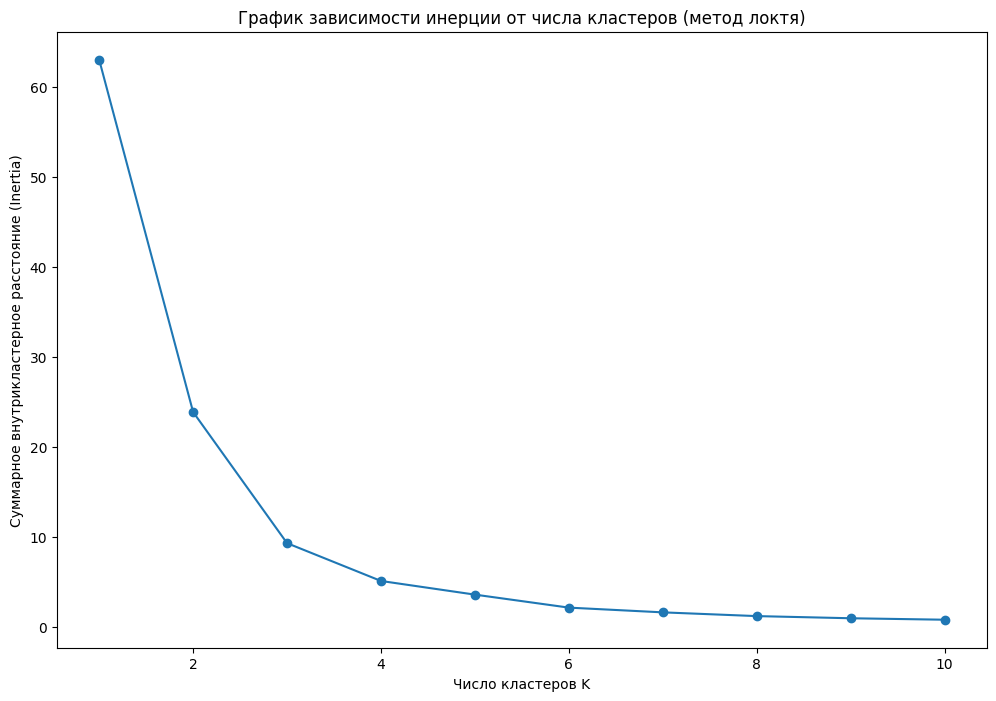

In [20]:
# определяем оптимальное количество кластеров
i = []

min_k = 1
max_k = 10

plt.figure(figsize=(12, 8))

for k in range(min_k, max_k + 1):
   km = KMeans(n_clusters=k)
   km.fit_transform(df_scaled_std)
   i.append(km.inertia_)

plt.plot(range(min_k, max_k + 1), i, marker='o')
plt.xlabel('Число кластеров K')
plt.ylabel('Суммарное внутрикластерное расстояние (Inertia)')
plt.title('График зависимости инерции от числа кластеров (метод локтя)')
plt.show()

Оптимальное количество кластеров - 4

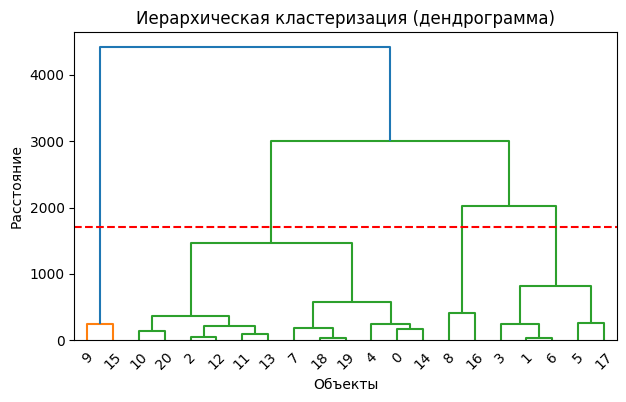

In [21]:
# Код ревьюера:
# Создадим таблицу связей:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(df_kmeans, method = 'ward')

# Визуализируем таблицу связей:
plt.figure(figsize=(7, 4))  
dendrogram(linked, orientation='top')

plt.axhline(y=1700, color='r', linestyle='--')  
plt.title("Иерархическая кластеризация (дендрограмма)")
plt.xlabel("Объекты")
plt.ylabel("Расстояние")

plt.show()

**Задача 4.3.**    
Проведём кластеризацию, проанализируем полученные результаты и рассчитаем средние значения по каждому кластеру.

После этого визуализируем результаты, чтобы проследить зависимость признаков друг от друга. Построим две визуализации, на которые нанесём все кластеры:

- средний чек в зависимости от количества заказов
- количество блюд в зависимости от количества заказов

После этого опишем каждый кластер в промежуточном выводе.

In [22]:
kmeans = KMeans(n_clusters=4, random_state=1)
labels = kmeans.fit_predict(df_kmeans)

# отсортируем кластеры по возрастанию revenue
sorted_indices = np.argsort(kmeans.cluster_centers_[:, 1])
sorted_centroids = kmeans.cluster_centers_[sorted_indices]


centroids_df = pd.DataFrame(
   sorted_centroids,
   columns=['orders_count', 'revenue_mean', 'unique_obj'],
   index=[f'Кластер {i + 1}' for i in range(kmeans.n_clusters)]
)

centroids_df

,orders_count,revenue_mean,unique_obj
Кластер 1,66.333333,1982.649367,8.333333
Кластер 2,1100.000000,2498.828802,83.000000
Кластер 3,77.000000,3120.901141,10.000000
Кластер 4,84.000000,4657.770196,2.500000


In [23]:
# функция построения тепловой карты
def heatmap_corr(df: pd.DataFrame):
    plt.figure(figsize = (12, 6))
    sns.heatmap(
        df,
        annot=True,
        fmt='.3f',
        cmap='Blues',
        center=0,
        linewidths=0.5, 
        cbar_kws={'label': 'Значение'}
    )
    plt.title(f'Матрица корреляции {df.columns[0]} с {df.columns[1]}')
    plt.show()

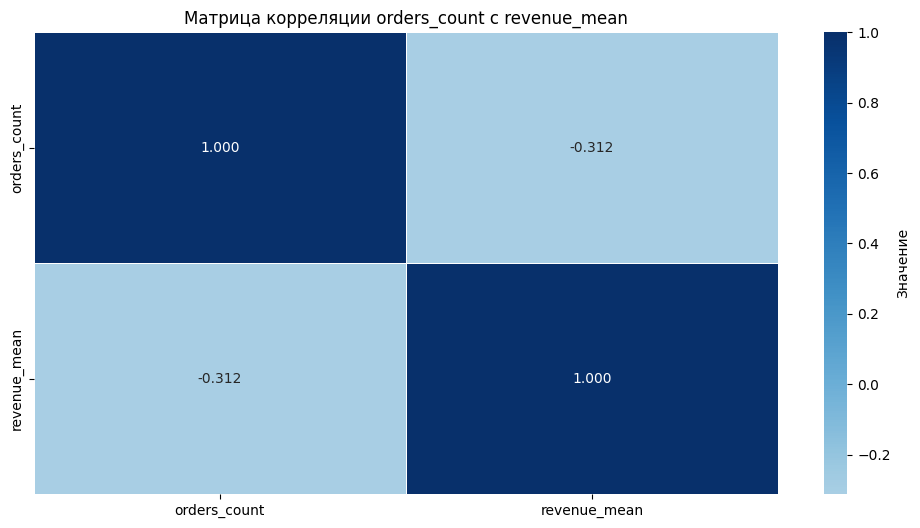

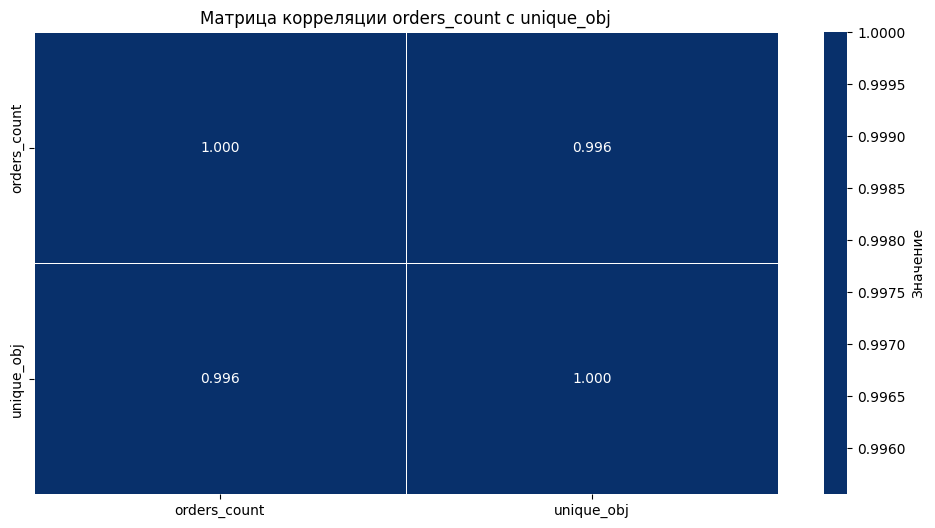

In [24]:
# построим визуализацию зависимости 
corr_rev_ord = centroids_df[['orders_count', 'revenue_mean']].corr() # среднего чека от количества заказов
corr_obj_ord = centroids_df[['orders_count', 'unique_obj']].corr() # количество уникальных блюд от количества заказов

heatmap_corr(corr_rev_ord)
heatmap_corr(corr_obj_ord)

## Промежуточный вывод.   
Между количеством уникальных блюд и количеством заказов высокая корреляция - 0,996. Между количеством заказов и средним чеком - отрицательная -0,312.     
`Кластер 1` - самое низкое количество заказов, низкий средний чек, количество уникальных блюд на третьем месте.    
`Кластер 2` - очень высокое количество заказов (1100 против 66-84 в других кластерах), умеренный средний чек, самое высокое количество уникальных блюд. Очевидно, что разнообразие блюд влияет на количество заказов, но средний чек низкий, возможно блюда дешевые. Необходимо работать над увеличением среднего чека.     
`Кластер 3` - третье место по количеству заказов, второе по среднему чеку. Количество уникальных блюд так же на втором месте.    
`Кластер 4` - самый перспективный кластер по среднему чеку (в 1,5 раза выше других кластеров, 4657 у.е.), на втором месте по количеству заказов. Но количество уникальных блюд самое малое - 2шт. Стоит работать над увеличением разнообразия блюд, что повлияет на увеличение количества заказов, но нужно следить за средним чеком и не допускать сильного снижения.     

---

## 5. Итоговый вывод и рекомендации

## Общий вывод.   

**1. Проблемы конверсии по платформам**
- **Desktop:** с шага `main_page` на `reg_page` переходят 79% пользователей. Вероятно, кнопка регистрации плохо заметна.
- **Mobile:** с шага `reg_page` на `confirm_phone` переходят только 55% пользователей. Регистрация на мобильных устройствах слишком сложна.

**2. Общие рекомендации по вовлечению (RFM)**
- Стимулировать частоту покупок через накопительные баллы.
- Добавить промокоды на покупку от определённой суммы для роста среднего чека.
- Программа кэшбэка уже действует: процент возврата растёт с суммой заказа, также даётся скидка за частые заказы.

**3. Приоритетные RFM-группы**
- **Самые важные, но малые по доле:** 333 (2,81%), 332 (0,21%), 323 (3,64%), 233 (4,22%). Требуют особого внимания.
- **Самые многочисленные:** 211, 212, 311, 312, 111. Для выравнивания их показателей нужны акции со скидками на количество блюд, кэшбэк за высокий средний чек, промокоды за частые визиты.
- **Группы для точечных акций** (213, 223, 233, 313, 323, 123, 113): персональные предложения по недостающим показателям.

**4. Зависимость уникальных блюд и числа заказов** – она сильная.

**5. Рекомендации для кластеров ресторанов**
- **Кластер 1:** увеличить разнообразие блюд для повышения вовлечённости.
- **Кластер 2:** много заказов, хороший средний чек, широкий ассортимент. Сфокусироваться на росте среднего чека.
- **Кластер 3:** увеличить разнообразие блюд – это повысит число заказов. Барьерная метрика – средний чек, не допускать его снижения.
- **Кластер 4:** высокий средний чек. Расширять ассортимент, но следить, чтобы средний чек не упал ниже заданного предела.